# Propose, Then Decide

**GLiNER2.5-Decide beside GLiNER2.5 — ontology-guided checks on extracted edges, typing ahead of entity
resolution, and the result loaded into Neo4j with every decision on it as a property. Two local models,
no API key.**

[GLiNER2.5-Decide](https://huggingface.co/fastino/GLiNER2.5-Decide) is the classification model in the
GLiNER2.5 family: the same `gliner2` library as the extractor every notebook here uses, a DeBERTa-v3-large
encoder, and one job — given a text and a label set passed at call time, return a probability for every
label. It finds no spans and generates no tokens. Its model card is about routing tickets and scoring
sentiment.

That shape is exactly the small judgments an extraction pipeline needs *between* stages, which
[notebook 10](10_typesafe_system_one.ipynb) answered with a hosted model:

- *is the sentence behind this edge a fact, or a possibility, a denial, a forecast?*
- *given the relations the ontology allows between these two types, is this the one the text states?*
- *what kind of thing does this mention name — so resolution can compare it with the right candidates?*
- *are these two mentions the same entity?*

So the division of labour tested here is **GLiNER2.5 proposes, Decide disposes**: the extractor finds
entities and edges against the ontology, and the classifier checks them against the same ontology. The
bar is notebook 10's, on the same corpus, the same gold triples and the same scoring. Where Decide
matches it, it does so on a laptop CPU; where it does not, the notebook says so and measures why.

| § | stage | Decide's question |
|---|---|---|
| 1 | one call | what the API returns, and the ontology as a label set |
| 2 | extraction | modality of each edge's sentences; which legal relation they state |
| 3 | resolution | the ontology type of each mention, as a second opinion for blocking |
| 4 | the graph | judgments as edge and node properties, not a filter |
| 5 | Neo4j | loading all of it, idempotently, and querying the judgments |

Four things turned out to matter more than any threshold, and they are worth knowing before reading the
numbers: **the label set is the question; Decide classifies the whole text, not a span inside it; the task
name is part of the prompt; and it verifies well but cannot find.** Each is measured where it first bites.

## 0. Setup

In [1]:
import os, sys, time, json, re, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 60)

import kgx
import kgx.decide as kd
from kgx.extract import DocGraph
from kgx.evaluate import score_triples, graph_triples, comparison_table, MatchPolicy
from kgx.data.documents import DOCUMENTS, ALIAS_GROUPS, MODALITY_TRAPS, GOLD_DOC_FACTS
from kgx.data.shopping import (DOCUMENTS as SHOP_DOCS, ALIAS_GROUPS as SHOP_ALIASES,
                               DISTINCT_PAIRS)
from kgx.domains import SHOPPING

ONTO = kgx.BUSINESS_NEWS
MATCH = MatchPolicy(normalize_names=True, use_aliases=True)

print(f"corpus   {len(DOCUMENTS)} business-news documents, {len(GOLD_DOC_FACTS)} gold triples, "
      f"{len(ALIAS_GROUPS)} gold alias groups, {len(MODALITY_TRAPS)} planted modality traps")
print(f"shopping {len(SHOP_DOCS)} documents, {len(DISTINCT_PAIRS)} pairs that must NOT merge")
print(f"ontology {len(ONTO.entities)} entity types, {len(ONTO.relations)} relations")

corpus   10 business-news documents, 47 gold triples, 13 gold alias groups, 11 planted modality traps
shopping 14 documents, 12 pairs that must NOT merge
ontology 13 entity types, 15 relations


Both models load through `gliner2`. They are separate checkpoints — the extractor is
`gliner2.5-base-v1` (194M), Decide is a DeBERTa-v3-large (the first run downloads about 1.9 GB) — so they
are two objects, not one set of shared weights the way `GlinerExtractor`'s two passes are.

In [2]:
extractor = kgx.GlinerExtractor()
judge = kd.DecideJudge()
print(extractor)
print(judge)

🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-large
Counting layer     : count_lstm
Token pooling      : first


<GlinerExtractor fastino/gliner2.5-base-v1 194M params loaded in 4.5s>
<DecideJudge fastino/GLiNER2.5-Decide 486M params on cpu, loaded in 5.7s>


---

## 1. What one decision looks like

### 1.1 One call, two heads

A schema is a set of **tasks**; each task is a name, a label set, and optionally an instruction. Several
tasks over one text are scored in one forward pass. `kgx.decide.DecideJudge` returns the full
distribution for every task, which is the point: most of what follows reads the *rest* of the
distribution, not just the winner.

The sentence is one of the planted traps — it has the surface shape of an acquisition and asserts the
opposite.

In [3]:
from gliner2.classification import ClassificationSchema

sentence = MODALITY_TRAPS[1]["sentence"]
schema = (ClassificationSchema()
          .single("modality", ["fact", "possibility", "denial", "forecast"])
          .single("industry", ["logistics", "semiconductors", "energy", "banking"]))

print(sentence, "\n")
for task, dist in judge.classify(sentence, schema).items():
    ranked = sorted(dist.items(), key=lambda kv: -kv[1])
    print(f"{task:9} " + "   ".join(f"{label} {p:.2f}" for label, p in ranked))

The Company does not expect to acquire additional terminal assets in 2026. 

modality  denial 0.99   fact 0.00   forecast 0.00   possibility 0.00
industry  logistics 0.36   banking 0.22   energy 0.22   semiconductors 0.20


The model card's own entry point, `classify_text`, runs the same model and keeps only the winner. That is
the right call for routing a ticket, and the wrong one for a pipeline stage — which is why
`DecideJudge` goes through `gliner2.classification.Classifier` instead.

In [4]:
judge.classifier.model.classify_text(
    sentence, {"modality": ["fact", "possibility", "denial", "forecast"]}, include_confidence=True)

{'modality': {'label': 'denial', 'confidence': 0.9794144034385681}}

### 1.2 The ontology is the label set

Nothing about Decide is specific to business news. The ontology already *is* the answer set for each
question the pipeline asks — the entity types for *what kind of thing is this*, and, for any ordered pair
of types, the relations the ontology permits between them for *which relationship is this*. `kgx.decide`
compiles both from `kgx.BUSINESS_NEWS` the same way `kgx.ontology` compiles the extractor's schema, so the
two models are held to one definition of the graph.

In [5]:
type_s, type_names = kd.type_schema(ONTO)
print("entity types, as Decide sees them:")
print("  ", type_s.task_spec("type").label_names)

legal = kd.legal_relations(ONTO)
rel_s, rel_names = kd.relation_schema("Northwind Logistics", "Cascade Freight Systems",
                                      legal[("company", "company")])
spec = rel_s.task_spec("relation")
print(f"\n{len(ONTO.relations)} relations -> {len(legal)} legal (head type, tail type) combinations")
print("for a company -> company pair:")
print("   instruction:", spec.instruction)
print("   labels:     ", spec.label_names)

entity types, as Decide sees them:
   ('company', 'person', 'regulator', 'product', 'business segment', 'geography', 'sector', 'security', 'financial metric', 'risk factor', 'litigation', 'business event', 'commodity')

15 relations -> 43 legal (head type, tail type) combinations
for a company -> company pair:
   instruction: How is Northwind Logistics related to Cascade Freight Systems?
   labels:      ('subsidiary of', 'acquires', 'has stake in', 'supplies', 'partners with', 'competes with', 'no relation')


Two mechanical details are baked into those helpers. Labels are plain words (`financial metric`, not
`financial_metric`), and `no relation` is always offered, because a question must be able to answer
*nothing fits*. And every surface string that goes into a label or an instruction passes through
`kd.clean`: `gliner2.classification` rejects parentheses and its own marker tokens in anything it injects
into the prompt, and a mention like `(NYSE: HLCN)` would otherwise fail the schema build.

---

## 2. Extraction — GLiNER2.5 proposes, Decide checks

### 2.1 The baseline, unchanged

GLiNER2.5 over the ten `BUSINESS_NEWS` documents, exactly as notebooks 01 and 10 run it, resolved and
scored against the 47 gold triples with the repo's standard alias-tolerant policy.

In [6]:
t0 = time.perf_counter()
graphs = extractor.extract_batch(DOCUMENTS, ONTO)
gliner_s = time.perf_counter() - t0
mentions = [m for g in graphs for m in g.mentions]
MENTION = {m.mention_id: m for m in mentions}

resolver = kgx.EntityResolver().learn_aliases(d["text"] for d in DOCUMENTS)
resolution = resolver.resolve(mentions)

def gate(doc_graphs, keep):
    """Rebuild the doc graphs keeping only edges whose (doc, head, relation, tail) ids are in `keep`."""
    return [DocGraph(doc_id=g.doc_id, text=g.text, mentions=list(g.mentions),
                     edges=[e for e in g.edges if (g.doc_id, e.head, e.type, e.tail) in keep],
                     feasible=g.feasible, meta=dict(g.meta)) for g in doc_graphs]

def score(doc_graphs, pin=None):
    kg = kgx.build_graph(doc_graphs, resolution, ONTO, pin=pin)
    return score_triples(graph_triples(kg), GOLD_DOC_FACTS, policy=MATCH, aliases=ALIAS_GROUPS)

baseline = score(graphs)
print(f"{len(mentions)} mentions, {sum(len(g.edges) for g in graphs)} edges from {len(graphs)} documents "
      f"in {gliner_s:.1f}s")
print(f"GLiNER2.5, ungated: P {baseline.precision:.3f}  R {baseline.recall:.3f}  F1 {baseline.f1:.3f}")

214 mentions, 170 edges from 10 documents in 7.2s
GLiNER2.5, ungated: P 0.279  R 0.404  F1 0.330


The same 214 mentions and 170 edges notebook 10 starts from — the extractor is deterministic — so every
comparison below is like for like.

### 2.2 The modality traps, and the idiom

`MODALITY_TRAPS` is eleven sentences planted in the corpus that look like facts and are not: conditionals,
denials, forecasts, a counterfactual, a claim attributed to an unnamed analyst. Five plain assertions from
the same corpus are the control, because a detector that answers *not a fact* to everything scores 11/11
on the traps alone.

Three ways of asking. The first two are notebook 10's questions moved across as literally as the API
allows — its four statuses with their full criteria as label descriptions, and its `factual` yes/no. The
third is Decide's own idiom: four short concept labels and nothing else.

In [7]:
from kgx.typesafe import ASSERTION_LEVELS     # notebook 10's criteria -- plain data, no SDK, no key

CONTROLS = [
    "Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a "
    "definitive agreement to acquire Cascade Freight Systems for $1.4 billion in cash and stock.",
    "Cascade Freight Systems operates 41 cross-dock terminals across the Pacific Northwest "
    "and reported revenue of $612 million in fiscal 2025.",
    "Priya Raman is Chief Executive Officer of Northwind Logistics.",
    "A single vendor, Torrent Microsystems, supplies the controller boards used in "
    "substantially all of our telematics hardware.",
    "Halcyon Semiconductor Corporation operates fabrication sites in Phoenix, Dresden and Penang.",
]

SHAPES = {
    "notebook 10's criteria as label descriptions": (
        ClassificationSchema().single("status", {k: kd.clean(v) for k, v in ASSERTION_LEVELS.items()}),
        "status", "asserted"),
    "notebook 10's `factual` as a yes/no question": (
        ClassificationSchema().single("factual", ["yes", "no"], instruction=(
            "If a knowledge graph recorded the relationship this sentence is about as a plain fact, "
            "would the graph be correct? A sentence saying something will NOT happen or is NOT "
            "planned does not make that thing a fact.")),
        "factual", "yes"),
    "short concept labels": (
        ClassificationSchema().single("modality", ["fact", "possibility", "denial", "forecast"]),
        "modality", "fact"),
}

trap_sentences = [t["sentence"] for t in MODALITY_TRAPS]
rows = []
for name, (schema, task, positive) in SHAPES.items():
    traps = [p[task] for p in judge.probabilities(trap_sentences, schema)]
    ctrls = [p[task] for p in judge.probabilities(CONTROLS, schema)]
    win = lambda d: max(d, key=d.get)
    rows.append({"shape": name,
                 "traps caught": f"{sum(win(d) != positive for d in traps)}/11",
                 "controls kept": f"{sum(win(d) == positive for d in ctrls)}/5",
                 "max P(fact) on a trap": round(max(d[positive] for d in traps), 2),
                 "min P(fact) on a control": round(min(d[positive] for d in ctrls), 2)})
IDIOM = pd.DataFrame(rows).set_index("shape")
IDIOM["separated"] = IDIOM["max P(fact) on a trap"] < IDIOM["min P(fact) on a control"]
display(IDIOM)

,traps caught,controls kept,max P(fact) on a trap,min P(fact) on a control,separated
shape,,,,,
notebook 10's criteria as label descriptions,11/11,2/5,0.08,0.15,True
notebook 10's `factual` as a yes/no question,9/11,0/5,0.56,0.24,False
short concept labels,11/11,5/5,0.35,0.47,True


**The label set is the question.** Notebook 10's criteria are good criteria, and for a model that reads
instructions they produced 11/11 with controls intact. Passed to Decide as label descriptions they catch
every trap by calling most of the controls not-a-fact too — only two of five survive. The distributions
do separate, so a threshold fitted to these sixteen sentences would work, but the argmax is wrong and a
threshold fitted to sixteen sentences is not a method. The yes/no version is worse: its probabilities
overlap, so no threshold separates a denial from a plain assertion. Four short words — `fact`,
`possibility`, `denial`, `forecast` — get all eleven traps and all five controls from the argmax, with no
instruction at all.

That is the model card's advice taken literally: Decide was trained on label sets like `refund_request`
and `speak_to_human`, and the label name is what it has learned to read. Every schema in `kgx.decide` is
written that way.

Per sentence, with the statuses the corpus assigns:

In [8]:
per = kd.judge_sentences(judge, trap_sentences + CONTROLS)
display(pd.DataFrame([{"kind": "trap" if i < 11 else "control",
                       "sentence": r["sentence"][:84] + "…",
                       "decide": r["modality"], "p_fact": round(r["p_fact"], 2),
                       "why (corpus)": MODALITY_TRAPS[i]["why"][:44] if i < 11 else ""}
                      for i, r in enumerate(per)]))

,kind,sentence,decide,p_fact,why (corpus)
0,trap,"The proposed acquisition, if approved by the Surface Tra...",forecast,0.32,hypothetical - conditional on regulatory app
1,trap,The Company does not expect to acquire additional termin...,denial,0.01,negated expectation - no acquisition relatio
2,trap,"Management has no plans to divest the Cascade brand, or ...",denial,0.00,"negated intent - a divestiture is denied, no"
3,trap,We may face supply disruptions if tariffs on imported se...,possibility,0.14,"mixed - the supplies(Torrent, Northwind) cla"
4,trap,"Should demand for expedited freight soften, margins in o...",forecast,0.23,hypothetical - inverted conditional; no marg
5,trap,If tariffs on Asian-fabricated controllers were imposed ...,forecast,0.17,counterfactual conditional - tariffs have no
6,trap,The company said it has no plans to divest the Dresden f...,denial,0.01,"negated intent, reported speech - denies a d"
7,trap,Duarte has acknowledged that the chipmaker may face fine...,not stated,0.01,hypothetical plus explicit negation - no fin
8,trap,The Company does not expect the SEC inquiry to delay tha...,possibility,0.05,negated expectation followed by a hedged con
9,trap,One noted that if diesel remains above $4.40 a gallon in...,possibility,0.09,"hypothetical, attributed to an unnamed analy"


That table uses the pipeline's actual modality schema (`kd.modality_schema()`), which adds a fifth label,
`not stated`, for §2.3: there, the text is the sentence an *edge* came from, and "this sentence does not
carry the claim at all" needs somewhere to go.

### 2.3 Checking the 170 edges

Two questions per edge, over the same text — the sentences the edge spans, from its first endpoint to
its last (`kd.edge_window`), not the whole document:

- **`modality`** — is that window a fact, a possibility, a denial, a forecast, or not a statement of this
  at all? This catches the modality traps: the right relation, presented the wrong way.
- **`relation`** — of the relations the ontology permits between the two endpoint types, which does the
  window state, or `no relation`? This catches extraction errors: a plain fact with the wrong label, or
  two entities the text does not connect. An edge **agrees** when Decide picks the relation GLiNER
  decoded.

The window, not the document, because Decide classifies the text it is given as a whole — §3.2 makes
that failure vivid for typing. And the two questions go in two passes rather than one two-task schema:
tasks that share a prompt change each other's answers, and combined, the modality head lost recall on the
gold triples.

In [9]:
t0 = time.perf_counter()
checks = kd.check_edges(judge, graphs, ONTO)
check_s = time.perf_counter() - t0
C = pd.DataFrame([c.as_record() for c in checks])

print(f"{len(checks)} edges checked in {check_s:.1f}s ({2 * len(checks)} forward passes)\n")
print("modality of the edge's window:")
print(C["modality"].value_counts().to_string())
print(f"\nDecide picks the relation GLiNER decoded: {int(C['agrees'].sum())} / {len(C)}")
print(f"kept (fact AND agrees): {int(C['keep'].sum())} / {len(C)}\n")
print(pd.crosstab(C["modality"] == "fact", C["agrees"],
                  rownames=["stated as fact"], colnames=["relation agrees"]).to_string())

170 edges checked in 33.7s (340 forward passes)

modality of the edge's window:
modality
fact           123
forecast        25
not stated      12
possibility      6
denial           4

Decide picks the relation GLiNER decoded: 130 / 170
kept (fact AND agrees): 95 / 170

relation agrees  False  True 
stated as fact               
False               12     35
True                28     95


The two questions fail on different edges, and that is why the gate needs both. Here are each of the
failure modes on their own — edges that pass one check and fail the other.

In [10]:
C["window words"] = [len(c.window.split()) for c in checks]
cols = ["doc_id", "head", "relation", "tail", "gliner", "modality", "p_fact", "decide_pick",
        "p_relation", "window words"]
print("── RIGHT RELATION, NOT STATED AS FACT  (the modality check catches these)")
display(C[C["agrees"] & (C["modality"] != "fact")].sort_values("gliner", ascending=False)[cols].head(8))
print("── STATED AS FACT, WRONG OR NO RELATION  (the relation check catches these)")
display(C[~C["agrees"] & (C["modality"] == "fact")].sort_values("gliner", ascending=False)[cols].head(8))

── RIGHT RELATION, NOT STATED AS FACT  (the modality check catches these)


,doc_id,head,relation,tail,gliner,modality,p_fact,decide_pick,p_relation,window words
99,d06,Halcyon,operates_in,Germany,0.977,possibility,0.194,operates_in,1.000,142
153,d09,Marcus Webb,officer_of,Northwind Logistics,0.973,forecast,0.330,officer_of,0.715,103
98,d06,Halcyon,operates_in,Germany,0.970,not stated,0.148,operates_in,1.000,170
95,d06,Halcyon,operates_in,Germany,0.966,not stated,0.112,operates_in,1.000,101
93,d06,Halcyon,faces_risk,fines,0.961,not stated,0.115,faces_risk,0.647,124
92,d06,Halcyon,faces_risk,fines,0.955,not stated,0.073,faces_risk,0.846,152
90,d06,Halcyon,faces_risk,fines,0.953,not stated,0.076,faces_risk,0.521,70
94,d06,Ana Duarte,officer_of,Halcyon,0.948,not stated,0.115,officer_of,0.496,124


── STATED AS FACT, WRONG OR NO RELATION  (the relation check catches these)


,doc_id,head,relation,tail,gliner,modality,p_fact,decide_pick,p_relation,window words
130,d08,Vantage Energy Partners,partners_with,Northwind Logistics Inc.,0.969,fact,0.752,supplies,0.175,65
129,d08,Vantage Energy Partners,partners_with,Northwind Logistics Inc.,0.956,fact,0.607,supplies,0.129,149
137,d08,Vantage Energy Partners,produces,diesel,0.927,fact,0.664,none,0.467,29
113,d07,Cascade Freight Systems,subsidiary_of,Northwind Logistics Inc.,0.913,fact,0.360,none,0.147,44
139,d08,Vantage Energy Partners,produces,diesel,0.893,fact,0.809,none,0.499,73
33,d01,Cascade Freight Systems,subsidiary_of,Northwind Logistics,0.883,fact,0.869,acquires,0.020,120
169,d10,Northwind Logistics,subsidiary_of,Halcyon,0.873,fact,0.971,competes_with,0.000,124
48,d04,Northwind Logistics,acquires,Halcyon Semiconductor Corporation,0.820,fact,0.973,partners_with,0.007,152


The second table is the relation check doing something no modality question can. `partners_with(Vantage,
Northwind)` is stated plainly and is the wrong relation — Decide picks `supplies`, which is the gold
triple; `acquires(Northwind, Halcyon)` and `subsidiary_of(Northwind, Halcyon)` are relations the text
does not state (notebook 10's judge put both below 0.2 on *does the document connect these at all*).

The first table needs reading more carefully, because it is not all catches. `faces_risk(Halcyon, fines)`
is one — the only sentence behind it is *"may face fines if the Commission ultimately finds against it"*.
But `operates_in(Halcyon, Germany)` appears four times, and it is a fact. GLiNER emits the same surface
triple once per `Halcyon` mention it anchors on, and each copy gets its own window: anchored far from
`Germany`, the window is a long passage about an antitrust inquiry and reads as `not stated`; anchored on
the sentence *"Halcyon operates in Germany through its Dresden fabrication site"*, it reads as `fact`.
Look at the window lengths. The copies are dropped, the fact is kept, and at the canonical level (§4) the
edge survives. The same is true of `officer_of(Marcus Webb, Northwind)`: stated as fact in d04's earnings
call, and read as `forecast` in the three documents where the window is a passage about a deal,
guidance, or a lawsuit. Every copy of both, with the start of its window:

In [11]:
copies = C[((C["head"] == "Halcyon") & (C["relation"] == "operates_in") & (C["tail"] == "Germany"))
           | ((C["head"] == "Marcus Webb") & (C["relation"] == "officer_of")
              & C["tail"].str.startswith("Northwind"))].copy()
copies["window starts"] = [checks[i].window[:70].replace("\n", " ") + "…" for i in copies.index]
display(copies[["doc_id", "head", "relation", "tail", "modality", "p_fact", "keep", "window words",
                "window starts"]])

,doc_id,head,relation,tail,modality,p_fact,keep,window words,window starts
7,d01,Marcus Webb,officer_of,Northwind Logistics Inc.,forecast,0.256,False,176,SEATTLE — Northwind Logistics Inc. (NASDAQ: NWL) today a...
51,d04,Marcus Webb,officer_of,Northwind Logistics,fact,0.961,True,160,Operator: Good morning and welcome to the Northwind Logi...
95,d06,Halcyon,operates_in,Germany,not stated,0.112,False,101,Torrent competes with Halcyon across automotive analog a...
96,d06,Halcyon,operates_in,Germany,fact,0.594,True,18,Halcyon operates in Germany through its Dresden fabricat...
98,d06,Halcyon,operates_in,Germany,not stated,0.148,False,170,The inquiry examines whether Halcyon conditioned volume ...
99,d06,Halcyon,operates_in,Germany,possibility,0.194,False,142,Halcyon said it is cooperating and that its agreements c...
105,d07,Marcus Webb,officer_of,Northwind Logistics Inc.,forecast,0.113,False,45,Northwind Logistics Inc. was filed in the United States ...
153,d09,Marcus Webb,officer_of,Northwind Logistics,forecast,0.330,False,103,SEATTLE — Northwind Logistics cut its full-year revenue ...


Note the `gliner` column in both tables above. The extractor's confidence does not predict either
failure: span-level confidence is about the decoding, not about the claim.

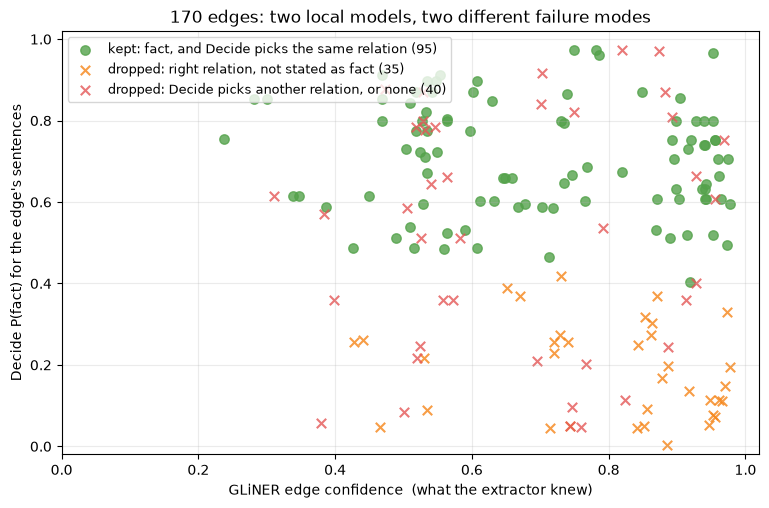

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5.5))
for (agrees, keep), (colour, marker, label) in {
        (True, True):   ("#54A24B", "o", "kept: fact, and Decide picks the same relation"),
        (True, False):  ("#F58518", "x", "dropped: right relation, not stated as fact"),
        (False, False): ("#E45756", "x", "dropped: Decide picks another relation, or none")}.items():
    sub = C[(C["agrees"] == agrees) & (C["keep"] == keep)]
    ax.scatter(sub["gliner"], sub["p_fact"], c=colour, marker=marker, s=46, alpha=0.8,
               label=f"{label} ({len(sub)})")
ax.set_xlabel("GLiNER edge confidence  (what the extractor knew)")
ax.set_ylabel("Decide P(fact) for the edge's sentences")
ax.set_xlim(0, 1.02); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.25)
ax.set_title(f"{len(C)} edges: two local models, two different failure modes")
ax.legend(loc="upper left", fontsize=9)
plt.show()

### 2.4 Does it help? Score against the gold triples

A gate can only remove triples, so recall can only fall and precision can only rise. Four rows from one
extraction pass and one checking pass: no gate, each check alone, and both.

In [13]:
def keep_set(pred):
    return {(c.doc_id, c.head_id, c.relation, c.tail_id) for c in checks if pred(c)}

GATES = {
    "GLiNER2.5, ungated":               None,
    "+ modality = fact":                keep_set(lambda c: c.asserted),
    "+ relation agrees":                keep_set(lambda c: c.agrees),
    "+ both  (the Decide gate)":        keep_set(lambda c: c.keep),
}
gate_scores = {name: (baseline if keep is None else score(gate(graphs, keep)))
               for name, keep in GATES.items()}
display(comparison_table(gate_scores))

decide_gate = gate_scores["+ both  (the Decide gate)"]
print("for reference, as recorded in notebook 10 (TypeSafe System One, hosted):")
print("   + TypeSafe assertion gate            P 0.404  R 0.404  F1 0.404")

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
+ both (the Decide gate),normalised + aliases,49,47,19,0.388,0.404,0.396
+ relation agrees,normalised + aliases,56,47,19,0.339,0.404,0.369
+ modality = fact,normalised + aliases,57,47,19,0.333,0.404,0.365
"GLiNER2.5, ungated",normalised + aliases,68,47,19,0.279,0.404,0.330


for reference, as recorded in notebook 10 (TypeSafe System One, hosted):
   + TypeSafe assertion gate            P 0.404  R 0.404  F1 0.404


**Each check alone helps a little; together they close most of the distance to notebook 10's hosted
gate, at no recall cost.** Recall stays exactly where the extractor left it — every gold triple GLiNER
found survives — while the predicted set shrinks.

They combine because they are close to independent. The modality check removes hedged claims whatever
their relation; the relation check removes mislabelled and unconnected pairs whatever their modality; and
the crosstab in §2.3 shows how few edges both reject.

### 2.5 How much of that is the wording?

§2.2 showed the labels are the question. In GLiNER2 **the task name is too**: it is encoded into the
prompt beside the labels, so `"modality"` and `"statement"` are different questions and give different
answers. `kgx.decide` uses `"modality"`, chosen for meaning before measuring. Here is what the other
names it could have used do — same labels, same windows, same relation check.

In [14]:
windows = [c.window for c in checks]
robust = []
for task in ["modality", "claim", "statement", "assertion", "m"]:
    out = judge.probabilities(windows, kd.modality_schema(task))
    fact = {c.key(): max(o[task], key=o[task].get) == kd.FACT for c, o in zip(checks, out)}
    both = keep_set(lambda c: fact[c.key()] and c.agrees)
    traps = [max(d, key=d.get) for d in
             (p[task] for p in judge.probabilities(trap_sentences, kd.modality_schema(task)))]
    s = score(gate(graphs, both))
    robust.append({"task name": repr(task), "edges kept": len(both),
                   "traps caught": f"{sum(t != kd.FACT for t in traps)}/11",
                   "precision": s.precision, "recall": s.recall, "f1": s.f1})

# and one wording that names the claim, the way notebook 10's instructions did
named = [ClassificationSchema().single("modality", list(kd.MODALITY_LABELS), instruction=(
            f"How does the text present the claim that {kd.clean(c.head)} "
            f"{kd.relation_label(c.relation)} {kd.clean(c.tail)}?")) for c in checks]
out = judge.probabilities(windows, named)
fact = {c.key(): max(o["modality"], key=o["modality"].get) == kd.FACT for c, o in zip(checks, out)}
both = keep_set(lambda c: fact[c.key()] and c.agrees)
s = score(gate(graphs, both))
robust.append({"task name": "'modality' + instruction naming the claim", "edges kept": len(both),
               "traps caught": "—", "precision": s.precision, "recall": s.recall, "f1": s.f1})

R = pd.DataFrame(robust).set_index("task name").round(3)
display(R)
print(f"F1 across task names: {R['f1'].iloc[:5].min():.3f} – {R['f1'].iloc[:5].max():.3f}  "
      f"(ungated {baseline.f1:.3f})")

,edges kept,traps caught,precision,recall,f1
task name,,,,,
'modality',95,11/11,0.388,0.404,0.396
'claim',90,11/11,0.383,0.383,0.383
'statement',84,11/11,0.409,0.383,0.396
'assertion',90,11/11,0.383,0.383,0.383
'm',88,11/11,0.404,0.404,0.404
'modality' + instruction naming the claim,103,—,0.380,0.404,0.392


F1 across task names: 0.383 – 0.404  (ungated 0.330)


The spread is real — a couple of hundredths of F1 from a word that carries no information the labels do
not — and it is worth reading as the honest error bar on §2.4 rather than as a knob. The best row is a
meaningless one-letter name, and picking it would be fitting the gold set. Two things hold across every
row: all eleven traps are caught, and every variant beats no gate.

Naming the claim in an instruction — the natural way to say *which* edge is being asked about — does not
help. The window already is the edge; the instruction is mostly noise to a model that reads labels.

### 2.6 Can it find edges, not just check them?

[Notebook 11](11_typesafe_relation_selection.ipynb) asked whether a judgment model could *raise* recall:
enumerate every co-occurring pair of mentions whose types the ontology connects, and ask which relation,
or none. Same question for Decide, at the same paragraph scope.

In [15]:
from kgx.typesafe import picks_to_graphs

def union(a_graphs, b_graphs):
    out = []
    for ga, gb in zip(a_graphs, b_graphs):
        seen = {(e.head, e.type, e.tail) for e in ga.edges}
        out.append(DocGraph(doc_id=ga.doc_id, text=ga.text, mentions=list(ga.mentions),
                            edges=list(ga.edges) + [e for e in gb.edges
                                                    if (e.head, e.type, e.tail) not in seen],
                            feasible=True, meta={}))
    return out

t0 = time.perf_counter()
picks = kd.select_relations(judge, graphs, ONTO, scope="paragraph")
select_s = time.perf_counter() - t0
n_picked = sum(p.picked for p in picks)
print(f"{len(picks)} candidate pairs in {select_s:.1f}s; a relation chosen for {n_picked} "
      f"({n_picked / len(picks):.0%}), `no relation` for {len(picks) - n_picked}\n")

sel = {}
for tau in (0.5, 0.9):
    sg = picks_to_graphs(graphs, picks, min_prob=tau)
    sel[f"Decide selection (p >= {tau})"] = score(sg)
    sel[f"GLiNER ∪ Decide selection (p >= {tau})"] = score(union(graphs, sg))
display(comparison_table({"GLiNER2.5 joint decoding": baseline, **sel}))
print("as recorded in notebook 11 (TypeSafe, same candidates): a relation for 105 of 295 (36%); "
      "selection F1 0.279; union F1 0.294")

295 candidate pairs in 12.8s; a relation chosen for 240 (81%), `no relation` for 55



,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
GLiNER2.5 joint decoding,normalised + aliases,68,47,19,0.279,0.404,0.330
GLiNER ∪ Decide selection (p >= 0.9),normalised + aliases,116,47,21,0.181,0.447,0.258
GLiNER ∪ Decide selection (p >= 0.5),normalised + aliases,239,47,24,0.100,0.511,0.168
Decide selection (p >= 0.5),normalised + aliases,208,47,17,0.082,0.362,0.133
Decide selection (p >= 0.9),normalised + aliases,59,47,7,0.119,0.149,0.132


as recorded in notebook 11 (TypeSafe, same candidates): a relation for 105 of 295 (36%); selection F1 0.279; union F1 0.294


**No.** Decide picks *some* relation for most pairs, where notebook 11's selector said `none` to nearly two
in three, and the precision of what it selects is a fraction of joint decoding's. The union adds recall —
selection does reach pairs the decoder missed — but buys it with so many wrong edges that F1 falls well
below the ungated baseline.

This is the same model that, in §2.4, reliably *confirmed* GLiNER's edges. The difference is the prior:
asked about an edge the extractor proposed, "which relation?" has a right answer most of the time; asked
about an arbitrary pair, the right answer is usually `no relation`, and a classifier trained on routing —
where every ticket has *some* queue — does not like choosing nothing. **Decide verifies; it does not find.**
Candidate generation stays GLiNER's job.

---

## 3. Resolution — typing ahead of blocking

### 3.1 The baseline, and the type wall

`kgx.EntityResolver` against the 13 gold alias groups, where notebooks 01, 05 and 10 put it: **precision
1.000, recall short of it.** Notebook 10 traced the missing recall to one cause. Blocking is type-scoped —
a `security` is never compared with a `company` — and the extractor typed `HLCN` as a ticker (a
`security`, which the ontology says tickers are) and `Halcyon Semiconductor` as a `company`. Both
readings are defensible, and the pair is never proposed.

In [16]:
GOLD = {}
for canon, aliases in ALIAS_GROUPS.items():
    surfaces = {a.strip() for a in aliases}
    for m in mentions:
        if m.text.strip() in surfaces:
            GOLD[m.mention_id] = canon

base_b3 = kgx.bcubed(resolution.mention_to_canon, GOLD)
blocking = resolver.blocking_report(mentions, GOLD)
print(f"{len(resolution.entities)} clusters from {len(mentions)} mentions ({len(GOLD)} gold-labelled)")
print(f"B-cubed   P {base_b3['precision']:.4f}  R {base_b3['recall']:.4f}  F1 {base_b3['f1']:.4f}")
print(f"blocking proposed {blocking['pair_completeness']:.1%} of gold-same pairs\n")

by_surface = {}
for m in mentions:
    by_surface.setdefault(m.text.strip(), set()).add(m.type)
print("surfaces behind the missing recall, and how GLiNER typed them:")
for s in ["HLCN", "NWL", "Halcyon Semiconductor Corporation", "Torrent Microsystems",
          "Vantage Energy Partners"]:
    print(f"  {s!r:38} {sorted(by_surface.get(s, []))}")

109 clusters from 214 mentions (77 gold-labelled)
B-cubed   P 1.0000  R 0.8972  F1 0.9458
blocking proposed 87.9% of gold-same pairs

surfaces behind the missing recall, and how GLiNER typed them:
  'HLCN'                                 ['security']
  'NWL'                                  ['company']
  'Halcyon Semiconductor Corporation'    ['company']
  'Torrent Microsystems'                 ['company', 'security']
  'Vantage Energy Partners'              ['company', 'security']


Notebook 10's fix was a second typing pass: ask a judgment model what each mention *refers to*, and let
blocking see an ambiguous mention under more than one type. That is a classification over the ontology's
entity types — squarely Decide's shape.

### 3.2 Type the mention, not the sentence

The obvious way to ask is the way notebook 10 did: the sentence as the text, an instruction naming the
mention. For Decide that does not work, and a handful of mentions shows why at a glance.

In [17]:
def sentence_of(m):
    g = next(g for g in graphs if g.doc_id == m.doc_id)
    return next(g.text[a:b] for a, b in kd.sentence_spans(g.text) if a <= m.start < b)

probe = []
for text in ["Marcus Webb", "revenue", "Surface Transportation Board", "Pacific Northwest", "HLCN"]:
    m = next(m for m in mentions if m.text == text)
    in_context = ClassificationSchema().single(
        "type", list(type_names), instruction=f"What kind of real-world thing does {kd.clean(text)} refer to?")
    ctx = judge.classify(sentence_of(m), in_context)["type"]
    bare = judge.classify(text, type_s)["type"]
    probe.append({"mention": text, "GLiNER": m.type,
                  "Decide, sentence + instruction": type_names[max(ctx, key=ctx.get)],
                  "Decide, surface only": type_names[max(bare, key=bare.get)],
                  "sentence": sentence_of(m)[:70] + "…"})
display(pd.DataFrame(probe))

,mention,GLiNER,"Decide, sentence + instruction","Decide, surface only",sentence
0,Marcus Webb,person,company,person,"""The proposed acquisition, if approved by the Surface Tr..."
1,revenue,financial_metric,company,financial_metric,Cascade Freight Systems operates 41 cross-dock terminals...
2,Surface Transportation Board,regulator,company,regulator,"""The proposed acquisition, if approved by the Surface Tr..."
3,Pacific Northwest,geography,company,geography,Cascade Freight Systems operates 41 cross-dock terminals...
4,HLCN,security,person,company,PHOENIX — Halcyon Semiconductor Corporation (NYSE: HLCN)...


**Decide classifies the text it is given, as a whole.** With the sentence in view it types the
*sentence* — which, in a corpus of filings about Northwind and Halcyon, is nearly always about a company —
and the instruction naming the mention barely steers it: `Marcus Webb`, `revenue` and the `Surface
Transportation Board` all come back `company`. Given only the surface string, it types the mention.

Across all 214 mentions:

In [18]:
in_context = [ClassificationSchema().single(
    "type", list(type_names), instruction=f"What kind of real-world thing does {kd.clean(m.text)} refer to?")
    for m in mentions]
ctx = judge.probabilities([sentence_of(m) for m in mentions], in_context)
ctx_agree = sum(type_names[max(p["type"], key=p["type"].get)] == m.type for m, p in zip(mentions, ctx))

opinions = kd.type_mentions(judge, mentions, ONTO)
bare_agree = sum(not o.changed for o in opinions)
print(f"agreement with GLiNER's type:  sentence + instruction {ctx_agree}/214   "
      f"surface only {bare_agree}/214")

agreement with GLiNER's type:  sentence + instruction 72/214   surface only 145/214


The surface-only answer has a price: with no context, a homograph cannot be read. `Cascade` could be a
company or a cascade of anything, and a context-free classifier has no way to tell. That decides how the
opinion is used. It does not *replace* the extractor's type — GLiNER saw the sentence, and its labels go
into the graph — it is offered to blocking as a **second opinion**.

In [19]:
T = pd.DataFrame([o.as_record() for o in opinions])
print(f"Decide disagrees with GLiNER on {int(T['changed'].sum())} of {len(T)} mentions; "
      f"the most confident disagreements:")
display(T[T["changed"]].drop_duplicates(subset=["text"]).sort_values("conf", ascending=False).head(12))
print("\nthe tickers:")
display(T[T["text"].isin(["HLCN", "NWL"])].drop_duplicates(subset=["text", "gliner"]))

Decide disagrees with GLiNER on 69 of 214 mentions; the most confident disagreements:


,doc_id,text,gliner,decide,conf,runner_up,p_runner_up,changed
133,d07,SEC,regulator,security,0.996,company,0.001,True
123,d06,fines,risk_factor,litigation,0.828,company,0.031,True
71,d04,adjusted EBITDA,security,financial_metric,0.665,company,0.072,True
179,d09,spot rack prices,risk_factor,commodity,0.637,financial_metric,0.097,True
136,d07,United States District Court,regulator,litigation,0.611,regulator,0.149,True
126,d06,Dresden fabrication site,company,geography,0.602,company,0.196,True
48,d03,supply disruptions,risk_factor,commodity,0.591,business_event,0.172,True
115,d06,telematics unit,business_segment,product,0.578,commodity,0.049,True
47,d03,Telematics unit,business_segment,product,0.578,commodity,0.049,True
210,d10,Vantage Energy Partners,security,company,0.548,sector,0.068,True



the tickers:


,doc_id,text,gliner,decide,conf,runner_up,p_runner_up,changed
28,d02,NWL,company,company,0.155,financial_metric,0.105,False
81,d05,HLCN,security,company,0.144,financial_metric,0.105,True


The disagreements are a mix, and the most confident one is a mistake. `SEC` as a `security` at 0.996 is
exactly what a reader with no context would say about a three-letter capitalised string; `United States
District Court` as `litigation` confuses the venue with the case. Beside those are real corrections —
`adjusted EBITDA` is a financial metric, not a security, and `Vantage Energy Partners` is a company — and
several defensible readings either way (`Dresden fabrication site` as a place, `spot rack prices` as a
commodity).

And note the confidences on the tickers. With thirteen labels and no context, Decide's distribution over
a bare string is flat: `HLCN` comes back `company` at 0.14, a plurality, not a verdict. Both points are
fine for a second opinion, whose only effect is to add a candidate for the resolver to reject.

### 3.3 The second opinion, applied

`kd.second_opinion` keeps every mention under GLiNER's type and adds a clone under Decide's type
wherever the two differ. The resolver runs unchanged over the augmented list; `kd.fold_clones` then
folds each clone back onto its original. A clone does not merge with anything by itself: it enters the
other type's block and the resolver's own scoring still has to accept every pair.

In [20]:
from kgx.typesafe import apply_types

augmented, clones = kd.second_opinion(mentions, opinions)
res_aug = resolver.resolve(augmented)
second = kd.fold_clones(res_aug.mention_to_canon, clones)
replaced = resolver.resolve(apply_types(mentions, opinions)).mention_to_canon

res_rows = []
for name, mapping in [("kgx.EntityResolver (GLiNER types)", resolution.mention_to_canon),
                      ("+ Decide's type instead of GLiNER's", replaced),
                      (f"+ Decide's type as a second opinion ({len(clones)} clones)", second)]:
    b = kgx.bcubed(mapping, GOLD)
    res_rows.append({"resolution": name, "clusters": len(set(mapping.values())),
                     "precision": round(b["precision"], 4), "recall": round(b["recall"], 4),
                     "f1": round(b["f1"], 4)})
display(pd.DataFrame(res_rows).set_index("resolution"))
print("as recorded in notebook 10 (TypeSafe re-typing, soft, 17 clones):  P 1.0000  R 1.0000  F1 1.0000")

,clusters,precision,recall,f1
resolution,,,,
kgx.EntityResolver (GLiNER types),109,1.0,0.8972,0.9458
+ Decide's type instead of GLiNER's,106,1.0,0.9619,0.9806
+ Decide's type as a second opinion (69 clones),103,1.0,1.0000,1.0000


as recorded in notebook 10 (TypeSafe re-typing, soft, 17 clones):  P 1.0000  R 1.0000  F1 1.0000


**B-cubed 1.000 at precision 1.000, with the resolver untouched** — the same endpoint notebook 10 reached
with a hosted model reading each mention in its document. Replacing GLiNER's type with Decide's does
nearly as well on the gold groups, but it would put Decide's context-free mistakes into the graph's
labels; the second opinion only ever widens candidate generation.

Which clusters did the second opinion actually join? The gold score says it merged the right things; this
says what else it merged.

In [21]:
from collections import defaultdict

members = defaultdict(list)
for mid, cid in second.items():
    members[cid].append(mid)
joined = []
for cid, mids in members.items():
    before = {resolution.mention_to_canon[m] for m in mids}
    if len(before) > 1:
        joined.append({"cluster": cid, "mentions": len(mids), "was clusters": len(before),
                       "types (GLiNER)": ", ".join(sorted({MENTION[m].type for m in mids})),
                       "surfaces": ", ".join(sorted({MENTION[m].text for m in mids}))[:90]})
display(pd.DataFrame(joined).sort_values("mentions", ascending=False))
print(f"clusters over 15 mentions: before {len(resolution.oversized(15))}, "
      f"after {sum(1 for m in members.values() if len(m) > 15)}")

,cluster,mentions,was clusters,types (GLiNER),surfaces
2,company:halcyon-semiconductor-corporation,14,2,"company, security","HLCN, Halcyon, Halcyon Semiconductor, Halcyon Semiconduc..."
0,company:cascade-freight-systems,6,2,"company, product","Cascade, Cascade Freight Systems, Cascade brand"
1,company:torrent-microsystems,5,2,"company, security",Torrent Microsystems
3,company:vantage-energy-partners,5,2,"company, security",Vantage Energy Partners
4,company:dresden-fabrication-site,2,2,"company, geography","Dresden, Dresden fabrication site"
5,business_segment:automotive,2,2,"business_segment, sector","Automotive, automotive"


clusters over 15 mentions: before 1, after 1


Three of the six joins are the point: `HLCN` into Halcyon, and two company names GLiNER typed `company` in
one sentence and `security` in another (`Torrent Microsystems`, `Vantage Energy Partners`).
`Automotive` / `automotive` is a segment-or-sector call that could go either way. The other two are
outside the gold groups, where B-cubed cannot see them, and they are debatable at best — `Dresden` the
city folded into `Dresden fabrication site`, and `Cascade brand` into the company. The resolver's scoring
accepted both, which is what it is for; they are the cost side of widening blocking, in the corpus where
that cost is lowest. §3.5 measures it where it is highest.

### 3.4 How much of that is the wording?

Same question as §2.5, for the type labels: the ontology's raw names, the mechanical plain-word version
`kgx.decide` uses by default, and everyday words written by hand for this ontology (before measuring —
`place` for `geography`, `lawsuit or investigation` for `litigation`). `type_mentions(labels=...)` takes
the mapping.

In [22]:
EVERYDAY = {"geography": "place", "sector": "industry sector", "risk_factor": "risk",
            "litigation": "lawsuit or investigation", "business_event": "corporate event"}

label_rows = []
for name, schema_fn, labels in [("raw names", None, {e.name: e.name for e in ONTO.entities}),
                                ("plain words (default)", None, None),
                                ("everyday words", None, EVERYDAY)]:
    ops = kd.type_mentions(judge, mentions, ONTO, labels=labels)
    aug, cl = kd.second_opinion(mentions, ops)
    b = kgx.bcubed(kd.fold_clones(resolver.resolve(aug).mention_to_canon, cl), GOLD)
    label_rows.append({"type labels": name, "agree with GLiNER": f"{sum(not o.changed for o in ops)}/214",
                       "clones": len(cl), "B-cubed P": round(b["precision"], 4),
                       "B-cubed R": round(b["recall"], 4)})
display(pd.DataFrame(label_rows).set_index("type labels"))

,agree with GLiNER,clones,B-cubed P,B-cubed R
type labels,,,,
raw names,147/214,67,1.0,1.0
plain words (default),145/214,69,1.0,1.0
everyday words,163/214,51,1.0,1.0


The words move agreement a lot and the outcome not at all. Better words mean fewer spurious clones —
less work for blocking, fewer chances to go wrong — not a different answer.

### 3.5 The other direction: pairs that must *not* merge

Everything above shows merges going right, and a stage that merges everything scores perfectly on a
corpus with no traps. The shopping corpus has them: `DISTINCT_PAIRS` is a list of product pairs that must
stay apart — `Aurora 14` / `Aurora 14 Pro`, `N600` / `N600X` — and notebook 09 found the resolver merges
three of them on its own. Widening blocking can only make that worse, so measure it.

In [23]:
shop_graphs = extractor.extract_batch(SHOP_DOCS, SHOPPING)
shop_mentions = [m for g in shop_graphs for m in g.mentions]
SHOP_MENTION = {m.mention_id: m for m in shop_mentions}
shop_resolver = kgx.EntityResolver().learn_aliases(d["text"] for d in SHOP_DOCS)
shop_resolution = shop_resolver.resolve(shop_mentions)

first_of = {}
for m in shop_mentions:                      # first mention of each surface
    first_of.setdefault(m.text.strip(), m)
testable = [(a, b) for a, b in DISTINCT_PAIRS if a in first_of and b in first_of]

def trap_merges(mapping):
    return [(a, b) for a, b in testable
            if mapping[first_of[a].mention_id] == mapping[first_of[b].mention_id]]

shop_ops = kd.type_mentions(judge, shop_mentions, SHOPPING)
shop_aug, shop_clones = kd.second_opinion(shop_mentions, shop_ops)
shop_res_aug = shop_resolver.resolve(shop_aug)
shop_second = kd.fold_clones(shop_res_aug.mention_to_canon, shop_clones)

before, after = trap_merges(shop_resolution.mention_to_canon), trap_merges(shop_second)
print(f"{len(shop_mentions)} shopping mentions; {len(testable)} must-split pairs present\n")
print(f"resolver alone           false merges {len(before)}/{len(testable)}: {before}")
print(f"+ second opinion ({len(shop_clones)} clones) false merges {len(after)}/{len(testable)}: "
      f"new: {sorted(set(after) - set(before))}")

318 shopping mentions; 11 must-split pairs present

resolver alone           false merges 3/11: [('Aurora 14', 'Aurora 14 Pro'), ('Northwind Router N600', 'Northwind Router N600X'), ('Halcyon Buds', 'Halcyon Buds Pro')]
+ second opinion (122 clones) false merges 4/11: new: [('Halcyon', 'Halcyon Buds')]


**One new false merge, and it is worth seeing how it happened**, because it is the general risk of
widening blocking in one example.

In [24]:
SHOP_AUG = {m.mention_id: m for m in shop_aug}
new = sorted(set(after) - set(before))
for a, b in new:
    for s in (a, b):
        o = next(o for o in shop_ops if o.text.strip() == s)
        top = sorted(o.probabilities.items(), key=lambda kv: -kv[1])[:3]
        print(f"{s!r:15} GLiNER {o.extractor_type:8}  Decide " + "  ".join(f"{t} {p:.2f}" for t, p in top))
    # accepted pairs where a clone of one side met the other side
    bridge = [p for p in shop_res_aug.pairs if p.score >= shop_res_aug.threshold
              and ("~" in p.a or "~" in p.b)
              and {SHOP_AUG[p.a].text.strip(), SHOP_AUG[p.b].text.strip()} == {a, b}]
    print(f"\n{len(bridge)} accepted pairs join them, every one through a clone:")
    for p in bridge[:4]:
        x, y = SHOP_AUG[p.a], SHOP_AUG[p.b]
        print(f"   {x.text!r} as {x.type} ({p.a})  ~  {y.text!r} as {y.type} ({p.b})  "
              f"score {p.score:.2f}, {p.block!r} block")

'Halcyon'       GLiNER brand     Decide brand 0.36  product 0.12  product_category 0.06
'Halcyon Buds'  GLiNER product   Decide brand 0.28  product 0.27  product_category 0.09

6 accepted pairs join them, every one through a clone:
   'Halcyon Buds' as brand (s06:e1~brand)  ~  'Halcyon' as brand (s06:e2)  score 0.93, 'head' block
   'Halcyon Buds' as brand (s06:e1~brand)  ~  'Halcyon' as brand (s06:e4)  score 0.91, 'head' block
   'Halcyon' as brand (s06:e4)  ~  'Halcyon Buds' as brand (s06:e5~brand)  score 0.95, 'head' block
   'Halcyon Buds' as brand (s06:e22~brand)  ~  'Halcyon' as brand (s06:e24)  score 0.91, 'head' block


GLiNER typed `Halcyon Buds` a product. Decide, reading the bare string, calls it a brand — by 0.28 to
0.27, a coin flip — so a brand clone of `Halcyon Buds` enters the brand block beside `Halcyon`, where the
resolver's head-token blocking and prefix scoring (the rule that correctly unites `Northwind` with
`Northwind Logistics Inc.`) accept it at over 0.9. Each step is locally reasonable; the merge is wrong.
And a margin of one hundredth on a context-free question was enough to cause it.

That is the trade in one line: on business news the second opinion recovers every missing gold merge,
and on shopping it costs one. What would catch it is a stage that asks *are these the same thing?* — so
ask Decide that.

### 3.6 Can Decide adjudicate a pair?

Notebook 10 filled the resolver's review band with one ordered score per pair. Three shapes for Decide,
scored on the business-news review band (every labelled pair there is a true merge) and on the
shopping pairs with known answers (must-split and must-merge).

In [25]:
band = resolution.review_band(low=0.70)
band_same = [(MENTION[p.a], MENTION[p.b]) for p in band
             if GOLD.get(p.a) and GOLD.get(p.a) == GOLD.get(p.b)]

shop_pairs = [(first_of[a], first_of[b], "different") for a, b in testable]
for canon, variants in SHOP_ALIASES.items():
    if canon in first_of:
        shop_pairs += [(first_of[canon], first_of[v], "same") for v in variants
                       if v != canon and v in first_of]

def names_only(pairs):
    schema = lambda a: ClassificationSchema().single(
        "answer", ["yes", "no"], instruction=f"Are these two names for the same {kd.type_label(a.type)}?")
    out = judge.probabilities([f"{a.text} / {b.text}" for a, b in pairs], [schema(a) for a, _ in pairs])
    return [o["answer"]["yes"] for o in out]

def ordinal_levels(pairs):
    schema = ClassificationSchema().ordinal("link", ["different", "related", "same"])
    out = judge.probabilities([f"A: {a.text} — {a.context}\nB: {b.text} — {b.context}" for a, b in pairs],
                              schema)
    return [o["link"]["same"] for o in out]

pair_rows = []
for name, fn in [("names only, yes/no", names_only),
                 ("both contexts, ordinal different/related/same", ordinal_levels),
                 ("both contexts, yes/no  (kd.same_referent)", lambda ps: kd.same_referent(judge, ps))]:
    p_band = fn(band_same)
    p_shop = fn([(a, b) for a, b, _ in shop_pairs])
    split = [p for p, (_, _, g) in zip(p_shop, shop_pairs) if g == "different"]
    same = [p for p, (_, _, g) in zip(p_shop, shop_pairs) if g == "same"]
    pair_rows.append({"shape": name,
                      "band: true merges accepted": f"{sum(p >= .5 for p in p_band)}/{len(p_band)}",
                      "shop: false merges": f"{sum(p >= .5 for p in split)}/{len(split)}",
                      "shop: true merges accepted": f"{sum(p >= .5 for p in same)}/{len(same)}",
                      "P(same), range": f"{min(p_band + p_shop):.2f} – {max(p_band + p_shop):.2f}"})
display(pd.DataFrame(pair_rows).set_index("shape"))

p_ctx = kd.same_referent(judge, [(a, b) for a, b, _ in shop_pairs])
display(pd.DataFrame([{"a": a.text, "b": b.text, "gold": g, "P(same), both contexts": round(p, 2),
                       "resolver merged": (a.text.strip(), b.text.strip()) in before}
                      for (a, b, g), p in zip(shop_pairs, p_ctx)]))

,band: true merges accepted,shop: false merges,shop: true merges accepted,"P(same), range"
shape,,,,
"names only, yes/no",29/34,6/11,4/6,0.32 – 0.70
"both contexts, ordinal different/related/same",0/34,0/11,3/6,0.00 – 0.94
"both contexts, yes/no (kd.same_referent)",15/34,2/11,4/6,0.00 – 0.79


,a,b,gold,"P(same), both contexts",resolver merged
0,Aurora 14,Aurora 14 Pro,different,0.08,True
1,Northwind Router N600,Northwind Router N600X,different,0.00,True
2,Halcyon Buds,Halcyon Buds Pro,different,0.00,True
3,Aurora 14,Aurora Dock,different,0.18,False
4,Aurora,Aurora 14,different,0.34,False
5,Halcyon,Halcyon Buds,different,0.08,False
6,Northwind,Northwind Router N600,different,0.29,False
7,two-year limited warranty,12-month manufacturer warranty,different,0.44,False
8,12-month manufacturer warranty,24-month manufacturer warranty,different,0.72,False
9,free two-day delivery,free standard shipping,different,0.64,False


**None of them is a matcher.** Each shape trades one column for another: comparing names alone accepts
most true merges and six of the eleven traps; reading both contexts refuses nine of the eleven traps, and
more than half of the review band's true merges with them; and the ordinal shape almost never puts its
mass on `same` at all.

One pattern in the per-pair table looked usable: with both contexts, the three variant pairs the resolver
wrongly merges — `Aurora 14 Pro`, `N600X`, `Buds Pro` — come back at or near zero. So try the narrowest
possible role — a **veto** on the pairs the resolver has already accepted, applied only below a low
threshold.

In [26]:
def veto(res, mentions_by_id, clones_map, tau=0.1):
    accepted = [p for p in res.pairs if p.score >= res.threshold]
    ask = [p for p in accepted
           if mentions_by_id[p.a].text.strip().lower() != mentions_by_id[p.b].text.strip().lower()]
    p_same = kd.same_referent(judge, [(mentions_by_id[p.a], mentions_by_id[p.b]) for p in ask])
    vetoed = {(p.a, p.b): ps for p, ps in zip(ask, p_same) if ps < tau}
    kept = [p for p in accepted if (p.a, p.b) not in vetoed]
    comps = kgx.EntityResolver.cluster(list(mentions_by_id), kept, 0.0)
    mapping = {mid: f"c{i}" for i, comp in enumerate(comps) for mid in comp}
    return kd.fold_clones(mapping, clones_map), vetoed

bn_by_id = {m.mention_id: m for m in augmented}
shop_by_id = {m.mention_id: m for m in shop_aug}
bn_veto, bn_vetoed = veto(res_aug, bn_by_id, clones)
shop_veto, shop_vetoed = veto(shop_res_aug, shop_by_id, shop_clones)

b = kgx.bcubed(bn_veto, GOLD)
print(f"business news: {len(bn_vetoed)} accepted pairs vetoed; B-cubed P {b['precision']:.4f} "
      f"R {b['recall']:.4f}")
for (a, c), p in list(bn_vetoed.items())[:4]:
    print(f"   vetoed  {bn_by_id[a].text!r} ~ {bn_by_id[c].text!r}  P(same) {p:.2f}")
print(f"\nshopping: {len(shop_vetoed)} accepted pairs vetoed:")
for (a, c), p in shop_vetoed.items():
    print(f"   vetoed  {shop_by_id[a].text!r} ~ {shop_by_id[c].text!r}  P(same) {p:.2f}")
print(f"false merges still standing: {trap_merges(shop_veto)}")

business news: 6 accepted pairs vetoed; B-cubed P 1.0000 R 1.0000
   vetoed  'Northwind Logistics Inc.' ~ 'Northwind Logistics'  P(same) 0.03
   vetoed  'Northwind Logistics Inc.' ~ 'Northwind Logistics'  P(same) 0.01
   vetoed  'Northwind Logistics Inc.' ~ 'Northwind Logistics'  P(same) 0.00
   vetoed  'Northwind Logistics Inc.' ~ 'Northwind Logistics'  P(same) 0.00

shopping: 4 accepted pairs vetoed:
   vetoed  'Aurora 14' ~ 'Aurora 14 Pro'  P(same) 0.00
   vetoed  'Aurora 14' ~ 'Aurora 14 Pro'  P(same) 0.00
   vetoed  'Halcyon Buds' ~ 'Halcyon Buds Pro'  P(same) 0.01
   vetoed  'Halcyon Buds' ~ 'Halcyon'  P(same) 0.08
false merges still standing: [('Aurora 14', 'Aurora 14 Pro'), ('Northwind Router N600', 'Northwind Router N600X'), ('Halcyon Buds', 'Halcyon Buds Pro'), ('Halcyon', 'Halcyon Buds')]


**The veto fails in both directions.** On business news it vetoes pairs as plain as `Northwind Logistics
Inc.` / `Northwind Logistics` with near-certainty — the gold score survives only because other accepted
pairs still connect them. On shopping it vetoes the right pairs and changes nothing, for the same reason:
clustering is connected components, and each false merge has more than one path.

So the resolution stage settles where extraction did. **Decide can say what a mention is. It cannot say
whether two mentions are the same thing** — which is a comparison between two texts, not a label for one,
and not a shape its training covers. Typing goes in front of blocking; the decision to merge stays with
the resolver's scoring, and the must-not-merge cases stay a job for an ontology rule or a model that reads
instructions (notebook 10 §3.8 got 0/11 false merges from one).

---

## 4. The graph — judgments as data

Everything Decide produced is a typed value with a probability, so none of it has to be spent at the point
of decision. Build the graph **ungated**, on the second-opinion clustering, and carry the checks up to the
canonical edges and the typing up to the canonical nodes. The gate from §2.4 then becomes a `WHERE`
clause — and a graph that remembers what the corpus *floated* is more useful than one that silently
dropped it.

`kd.aggregate_checks` carries each document-level check to the canonical edge its endpoints resolved to.
Several sentences can support one canonical edge; the representative is the best by *kept, then stated as
fact, then P(fact)* — an edge stated clearly once and hedged twice is still stated clearly once.

In [27]:
from collections import Counter

kg = kgx.build_graph(graphs, resolution, ONTO, pin=second)
canon_check = kd.aggregate_checks(checks, second)

opinion_of = {o.mention_id: o for o in opinions}
def node_typing(ent):
    ops = [opinion_of[m] for m in ent.mentions if m in opinion_of]
    votes = Counter(o.type for o in ops)
    gliner = Counter(MENTION[m].type for m in ent.mentions if m in MENTION)
    return {"decide_type": votes.most_common(1)[0][0] if votes else None,
            "decide_type_share": round(votes.most_common(1)[0][1] / len(ops), 3) if ops else None,
            "gliner_types": sorted(gliner)}

print(kg.summary())
print(f"\n{len(kg.edges)} canonical edges, {sum(1 for e in kg.edges if e.key() in canon_check)} carry a check")
print(pd.Series([canon_check[e.key()].modality for e in kg.edges if e.key() in canon_check])
        .value_counts().to_string())

KnowledgeGraph: 103 entities, 68 edges
  node labels: {'geography': 22, 'financial_metric': 19, 'product': 9, 'business_segment': 9, 'business_event': 7, 'person': 7, 'company': 7, 'risk_factor': 6, 'regulator': 5, 'sector': 5, 'security': 4, 'commodity': 3}
  edge types:  {'operates_in': 16, 'reports_metric': 13, 'officer_of': 7, 'produces': 7, 'partners_with': 6, 'competes_with': 4, 'participant_in': 4, 'subsidiary_of': 4, 'faces_risk': 4, 'acquires': 2, 'impacts': 1}

68 canonical edges, 68 carry a check
fact          57
forecast       8
not stated     2
denial         1


The check that this is the *same* gate and not a similar one: filtering the annotated graph on `keep`
must reproduce a graph built from the gated document graphs, triple for triple.

In [28]:
kept_ids = keep_set(lambda c: c.keep)
built_gated = set(kgx.build_graph(gate(graphs, kept_ids), resolution, ONTO, pin=second).triples())
filtered = {(kg.name(e.head), e.type, kg.name(e.tail)) for e in kg.edges
            if e.key() in canon_check and canon_check[e.key()].keep}
print(f"gated, then built    : {len(built_gated)} triples")
print(f"built, then filtered : {len(filtered)} triples")
print(f"identical: {filtered == built_gated}")

gated, then built    : 49 triples
built, then filtered : 49 triples
identical: True


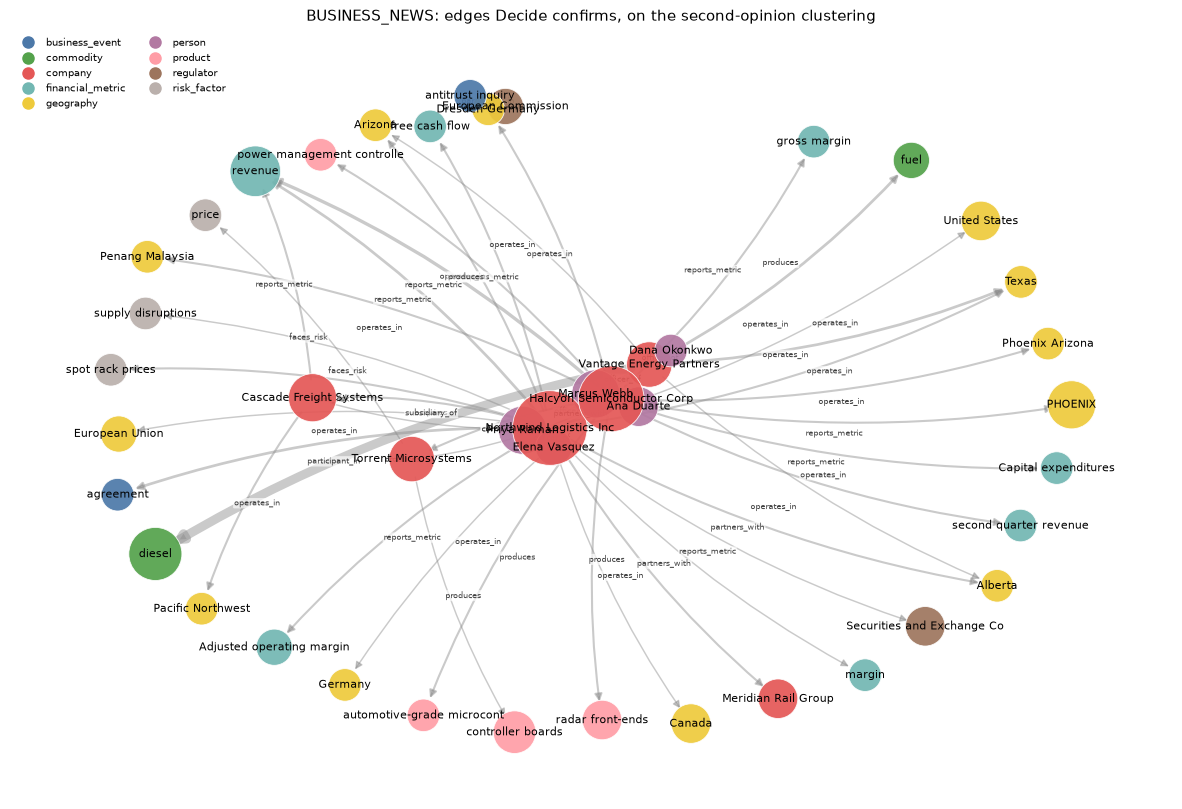

In [29]:
kg_kept = kgx.build_graph(gate(graphs, kept_ids), resolution, ONTO, pin=second)
kgx.draw(kg_kept, min_support=1, figsize=(15, 10),
         title="BUSINESS_NEWS: edges Decide confirms, on the second-opinion clustering")
plt.show()

---

## 5. Into Neo4j

The graph goes into the same Neo4j the other notebooks use (`bash scripts/neo4j_up.sh` brings it up on
`bolt://localhost:7690`; override with `NEO4J_URI`, `NEO4J_USER`, `NEO4J_PASSWORD`). Neo4j Community has
one database and [notebook 02](02_neo4j_graphrag_retrieval.ipynb)'s graph is already in it, so everything
here is **namespaced**: every `canon_id` and `doc_id` is prefixed `decide:`, and every node carries a
`__Decide__` label so the whole partition can be selected, or removed, in one clause.

`kgx.neo4j_io.load_graph` does the core of this in one call. It is written out here instead, because
the point of the section is the import itself — the row shapes, the Cypher, and where the Decide
judgments go.

### 5.1 Connect

In [30]:
import neo4j
from kgx.neo4j_io import (Neo4jConfig, connect, counts, label_for, rel_type_for,
                          supports_dynamic_labels, ENTITY_LABEL)

NS, PARTITION = "decide", "__Decide__"
config = Neo4jConfig.from_env(uri=os.environ.get("NEO4J_URI", "bolt://localhost:7690"),
                              user=os.environ.get("NEO4J_USER", "neo4j"),
                              password=os.environ.get("NEO4J_PASSWORD", "sandbox-kg"))
try:
    if "driver" in globals():
        driver.close()
    driver = connect(config, notifications="OFF")
    NEO4J = True
except Exception as exc:                      # the rest of §5 skips; §5.6 still writes a script
    NEO4J = False
    print(f"Neo4j not reachable at {config.uri} ({type(exc).__name__}). "
          f"Run `bash scripts/neo4j_up.sh`, or skip to §5.6 for an offline Cypher script.")

if NEO4J:
    # Clear what a previous run of THIS notebook left, so re-running is idempotent.
    records, _, _ = driver.execute_query(
        f"MATCH (n:{PARTITION}) WITH n LIMIT 100000 DETACH DELETE n RETURN count(*) AS removed")
    baseline_db = counts(driver)
    print(f"connected to {config.uri}")
    print(f"cleared {records[0]['removed']} nodes from a previous run of this notebook")
    print(f"already present: {baseline_db['nodes']} nodes, {baseline_db['relationships']} relationships")
    print(f"dynamic labels (MERGE (n:$(label))): {supports_dynamic_labels(driver)}")

connected to bolt://localhost:7690
cleared 113 nodes from a previous run of this notebook
already present: 119 nodes, 241 relationships
dynamic labels (MERGE (n:$(label))): True


Dynamic labels — `MERGE (n:$(row.label) …)` — are what let one parameterised statement write nodes of
thirteen different ontology labels; they need Neo4j 5.26 or later. On an older server,
`kgx.neo4j_io.load_graph(method="grouped")` falls back to one statement per label.

### 5.2 The rows

One row per canonical entity and one per canonical edge, as plain dicts of Cypher-safe values. The Decide
layer is ordinary properties: on nodes, the majority Decide type beside GLiNER's; on relationships, the
modality, P(fact), Decide's own relation pick, and the gate outcome, next to the evidence snippets that
justify the edge.

In [31]:
ns = lambda cid: f"{NS}:{cid}"

node_rows = []
for cid, ent in kg.entities.items():
    node_rows.append({
        "canon_id": ns(cid),
        "label": label_for(ent.type),
        "props": {"name": ent.canonical, "type": ent.type, "aliases": list(ent.aliases),
                  "n_mentions": len(ent.mentions), "docs": [ns(d) for d in sorted(set(ent.docs))],
                  **node_typing(ent)},
    })

edge_rows = []
for e in kg.edges:
    c = canon_check.get(e.key())
    evidence = sorted(e.evidence, key=lambda ev: -ev.confidence)
    edge_rows.append({
        "head": ns(e.head), "tail": ns(e.tail), "type": rel_type_for(e.type),
        "props": {"relation": e.type, "confidence": round(e.confidence, 4), "support": e.support,
                  "docs": sorted({ns(ev.doc_id) for ev in e.evidence}),
                  "evidence": [ev.snippet for ev in evidence[:3]],
                  **({"modality": c.modality, "p_fact": round(c.p_fact, 4),
                      "decide_pick": c.relation_choice, "p_relation": round(c.p_relation, 4),
                      "agrees": c.agrees, "keep": c.keep} if c else {})},
    })

doc_rows = [{"doc_id": ns(d["doc_id"]),
             "props": {"title": d["title"], "date": d["date"], "source": d["source"], "text": d["text"]},
             "entities": [ns(cid) for cid, ent in kg.entities.items() if d["doc_id"] in ent.docs]}
            for d in DOCUMENTS]

print(f"{len(node_rows)} node rows, {len(edge_rows)} relationship rows, {len(doc_rows)} document rows\n")
print(json.dumps(next(r for r in node_rows if r["props"]["name"].startswith("Halcyon Semi")), indent=2))
print(json.dumps(next(r for r in edge_rows if r["props"].get("modality") not in (None, "fact")), indent=2))

103 node rows, 68 relationship rows, 10 document rows

{
  "canon_id": "decide:company:halcyon-semiconductor-corporation",
  "label": "Company",
  "props": {
    "name": "Halcyon Semiconductor Corporation",
    "type": "company",
    "aliases": [
      "HLCN",
      "Halcyon",
      "Halcyon Semiconductor"
    ],
    "n_mentions": 14,
    "docs": [
      "decide:d04",
      "decide:d05",
      "decide:d06",
      "decide:d08",
      "decide:d10"
    ],
    "decide_type": "company",
    "decide_type_share": 1.0,
    "gliner_types": [
      "company",
      "security"
    ]
  }
}
{
  "head": "decide:company:northwind-logistics-inc",
  "tail": "decide:business_event:acquisition",
  "type": "PARTICIPANT_IN",
  "props": {
    "relation": "participant_in",
    "confidence": 0.743,
    "support": 4,
    "docs": [
      "decide:d01"
    ],
    "evidence": [
      "xecutive Officer of Northwind Logistics. \"The proposed acquisition, if approved by the",
      "tics. \"The proposed acquisition, 

### 5.3 Constraints, then nodes, relationships and documents

Constraints first: a uniqueness constraint creates the index that turns each `MERGE` from a label scan
into a lookup. Everything is `MERGE` on the namespaced id, so running this cell twice changes nothing —
which the cell checks.

In [32]:
CONSTRAINTS = [
    f"CREATE CONSTRAINT decide_entity_id IF NOT EXISTS FOR (n:{PARTITION}) REQUIRE n.canon_id IS UNIQUE",
]

NODES = """
UNWIND $rows AS row
MERGE (n:$(row.label) {canon_id: row.canon_id})
SET n:$($entity):$($partition), n += row.props
"""

RELATIONSHIPS = """
UNWIND $rows AS row
MATCH (h:$($partition) {canon_id: row.head})
MATCH (t:$($partition) {canon_id: row.tail})
MERGE (h)-[r:$(row.type)]->(t)
SET r += row.props
"""

DOCS = """
UNWIND $rows AS row
MERGE (d:Document {doc_id: row.doc_id})
SET d:$($partition), d += row.props
WITH d, row
UNWIND row.entities AS cid
MATCH (n:$($partition) {canon_id: cid})
MERGE (n)-[:MENTIONED_IN]->(d)
"""

def load():
    for statement in CONSTRAINTS:
        driver.execute_query(statement)
    params = {"entity": ENTITY_LABEL, "partition": PARTITION}
    driver.execute_query(NODES, rows=node_rows, **params)
    driver.execute_query(RELATIONSHIPS, rows=edge_rows, **params)
    driver.execute_query(DOCS, rows=doc_rows, **params)
    records, _, _ = driver.execute_query(
        f"MATCH (n:{PARTITION}) OPTIONAL MATCH (n)-[r]->() RETURN count(DISTINCT n) AS nodes, count(r) AS rels")
    return records[0]["nodes"], records[0]["rels"]

if NEO4J:
    t0 = time.perf_counter()
    first = load()
    load_s = time.perf_counter() - t0
    second_run = load()
    print(f"loaded {first[0]} nodes and {first[1]} relationships in {load_s:.2f}s")
    print(f"loaded again: {second_run[0]} nodes, {second_run[1]} relationships  -> idempotent: {first == second_run}")
    after_db = counts(driver)
    print(f"database now: {after_db['nodes']} nodes ({after_db['nodes'] - baseline_db['nodes']} added by this notebook)")

loaded 113 nodes and 238 relationships in 0.07s
loaded again: 113 nodes, 238 relationships  -> idempotent: True
database now: 232 nodes (113 added by this notebook)


### 5.4 Querying the judgments

The shape first — read back from the data, which is what a text2cypher prompt should be given — and then
the questions the Decide properties make answerable.

In [33]:
def q(cypher, **params):
    if not NEO4J:
        print("(skipped: no Neo4j)"); return None
    records, _, _ = driver.execute_query(cypher, routing_=neo4j.RoutingControl.READ, **params)
    return pd.DataFrame([dict(r) for r in records])

display(q(f"""
MATCH (a:{PARTITION})-[r]->(b:{PARTITION}) WHERE r.relation IS NOT NULL
RETURN labels(a)[0] AS head, type(r) AS relationship, labels(b)[0] AS tail,
       count(*) AS edges, sum(CASE WHEN r.keep THEN 1 ELSE 0 END) AS kept
ORDER BY edges DESC LIMIT 12
"""))

,head,relationship,tail,edges,kept
0,Company,OPERATES_IN,Geography,15,15
1,Company,REPORTS_METRIC,FinancialMetric,13,9
2,Person,OFFICER_OF,Company,7,6
3,Company,PRODUCES,Product,5,4
4,Company,PARTNERS_WITH,Company,5,3
5,Company,SUBSIDIARY_OF,Company,4,1
6,Company,FACES_RISK,RiskFactor,4,3
7,Company,COMPETES_WITH,Company,4,2
8,Company,PARTICIPANT_IN,BusinessEvent,3,1
9,Company,ACQUIRES,Company,2,1


**The facts both models stand behind** — the gate from §2.4, as a predicate:

In [34]:
display(q(f"""
MATCH (a:{PARTITION})-[r]->(b:{PARTITION})
WHERE r.keep
RETURN a.name AS head, type(r) AS rel, b.name AS tail, r.p_fact AS p_fact, r.support AS support
ORDER BY r.support DESC, r.p_fact DESC LIMIT 12
"""))

,head,rel,tail,p_fact,support
0,Vantage Energy Partners,PRODUCES,diesel,0.8564,15
1,Northwind Logistics Inc,REPORTS_METRIC,revenue,0.5380,7
2,Priya Raman,OFFICER_OF,Northwind Logistics Inc,0.8690,5
3,Northwind Logistics Inc,ACQUIRES,Cascade Freight Systems,0.7988,5
4,Halcyon Semiconductor Corporation,OPERATES_IN,Germany,0.5944,5
5,Marcus Webb,OFFICER_OF,Northwind Logistics Inc,0.9610,4
6,Halcyon Semiconductor Corporation,REPORTS_METRIC,revenue,0.8478,4
7,Northwind Logistics Inc,PARTNERS_WITH,Securities and Exchange Commission,0.6081,4
8,Northwind Logistics Inc,PARTNERS_WITH,Meridian Rail Group,0.9727,3
9,Northwind Logistics Inc,REPORTS_METRIC,Adjusted operating margin,0.9121,3


A filter, not an oracle: `PARTNERS_WITH` the Securities and Exchange Commission is an extraction error
(the company is *subject to* the SEC's inquiry) that both checks let through — the window states a fact,
and of the two relations the ontology allows from a company to a regulator, `partners with` and
`subject to`, Decide picks the wrong one too.

**What the corpus raised but did not assert** — every edge whose best supporting sentence is not a
statement of fact, which a gate would have deleted, still in the graph with the sentence behind it:

In [35]:
display(q(f"""
MATCH (a:{PARTITION})-[r]->(b:{PARTITION})
WHERE r.modality IS NOT NULL AND r.modality <> 'fact'
RETURN a.name AS head, type(r) AS rel, b.name AS tail, r.modality AS modality,
       round(r.p_fact, 2) AS p_fact, r.evidence[0] AS evidence
ORDER BY r.modality, r.confidence DESC
"""))

,head,rel,tail,modality,p_fact,evidence
0,Northwind Logistics Inc,REPORTS_METRIC,synergy estimates,denial,0.08,"e review. Shares of NWL closed 1.8% lower. Separately, N..."
1,Northwind Logistics Inc,PARTICIPANT_IN,transaction,forecast,0.42,ssets in 2026. The transaction has been unanimously appr...
2,Northwind Logistics Inc,PARTICIPANT_IN,acquisition,forecast,0.27,"xecutive Officer of Northwind Logistics. ""The proposed a..."
3,Northwind Logistics Inc,REPORTS_METRIC,margins,forecast,0.23,"ard of Directors of Northwind Logistics Inc. (the ""Compa..."
4,Torrent Microsystems,SUBSIDIARY_OF,Northwind Logistics Inc,forecast,0.21,and welcome to the Northwind Logistics fourth quarter an...
5,Northwind Logistics Inc,REPORTS_METRIC,operating margin,forecast,0.37,SEATTLE — Northwind Logistics cut its full-year revenue ...
6,Northwind Logistics Inc,OPERATES_IN,freight,forecast,0.39,SEATTLE — Northwind Logistics cut its full-year revenue ...
7,Northwind Logistics Inc,PRODUCES,controller boards,forecast,0.26,Officer: Thank you. Northwind delivered full year revenu...
8,Northwind Logistics Inc,PARTNERS_WITH,Vantage Energy Partners,forecast,0.06,and welcome to the Northwind Logistics fourth quarter an...
9,Halcyon Semiconductor Corporation,FACES_RISK,fines,not stated,0.11,closed competition. Halcyon said it is cooperating and t...


**Where the two models disagree about the relation** — a review queue, ordered by how little probability
Decide gives the relation GLiNER decoded:

In [36]:
display(q(f"""
MATCH (a:{PARTITION})-[r]->(b:{PARTITION})
WHERE r.decide_pick IS NOT NULL AND NOT r.agrees
RETURN a.name AS head, r.relation AS gliner, r.decide_pick AS decide, b.name AS tail,
       r.modality AS modality, r.evidence[0] AS evidence
ORDER BY r.p_relation ASC LIMIT 10
"""))

,head,gliner,decide,tail,modality,evidence
0,Northwind Logistics Inc,partners_with,acquires,Cascade Freight Systems,fact,ted average price. Cascade Freight Systems operates 41 c...
1,Meridian Rail Group,subsidiary_of,partners_with,Northwind Logistics Inc,fact,"s had lobbied for. Northwind Logistics, the Seattle-base..."
2,Northwind Logistics Inc,subsidiary_of,competes_with,Halcyon Semiconductor Corporation,fact,er: Good afternoon. Halcyon delivered second quarter rev...
3,Cascade Freight Systems,competes_with,acquires,Northwind Logistics Inc,fact,ted average price. Cascade Freight Systems operates 41 c...
4,Vantage Energy Partners,competes_with,supplies,Halcyon Semiconductor Corporation,fact,HOUSTON — Vantage Energy Partners today announced a thre...
5,Torrent Microsystems,subsidiary_of,supplies,Northwind Logistics Inc,forecast,and welcome to the Northwind Logistics fourth quarter an...
6,Northwind Logistics Inc,acquires,partners_with,Halcyon Semiconductor Corporation,fact,and welcome to the Northwind Logistics fourth quarter an...
7,Thomas Ingersoll,officer_of,none,Northwind Logistics Inc,fact,"ard of Directors of Northwind Logistics Inc. (the ""Compa..."
8,Northwind Logistics Inc,reports_metric,none,total contract value,not stated,"inancial Officer of Northwind Logistics, said the agreem..."
9,Northwind Logistics Inc,reports_metric,none,synergy estimates,denial,"e review. Shares of NWL closed 1.8% lower. Separately, N..."


**The entities resolution joined across types**, and the document trail for one of them. `HLCN` and
`Halcyon Semiconductor` are one node because a second opinion let blocking compare them, and the node
remembers both types:

In [37]:
display(q(f"""
MATCH (n:{PARTITION}:{ENTITY_LABEL})
WHERE size(n.gliner_types) > 1
RETURN n.name AS entity, n.type AS type, n.gliner_types AS gliner_types, n.decide_type AS decide_type,
       n.n_mentions AS mentions, n.aliases[0..5] AS aliases
ORDER BY n.n_mentions DESC
"""))

display(q(f"""
MATCH (h:{PARTITION} {{name: $name}})-[r]->(t:{PARTITION})
WHERE r.keep
MATCH (h)-[:MENTIONED_IN]->(d:Document)<-[:MENTIONED_IN]-(t)
RETURN type(r) AS rel, t.name AS tail, collect(DISTINCT d.title)[0..2] AS documents
LIMIT 8
""", name="Halcyon Semiconductor Corporation"))

,entity,type,gliner_types,decide_type,mentions,aliases
0,Halcyon Semiconductor Corporation,company,"[company, security]",company,14,"[HLCN, Halcyon, Halcyon Semiconductor]"
1,Cascade Freight Systems,company,"[company, product]",product,6,"[Cascade, Cascade brand]"
2,Vantage Energy Partners,company,"[company, security]",company,5,[]
3,Torrent Microsystems,company,"[company, security]",company,5,[]
4,Automotive,business_segment,"[business_segment, sector]",company,2,[automotive]
5,Dresden fabrication site,company,"[company, geography]",company,2,[Dresden]


,rel,tail,documents
0,OPERATES_IN,Penang Malaysia,[Halcyon Semiconductor Names Ana Duarte Chief Executive ...
1,REPORTS_METRIC,second quarter revenue,[Halcyon Semiconductor Corporation Second Quarter 2026 E...
2,OPERATES_IN,PHOENIX,[Halcyon Semiconductor Corporation Second Quarter 2026 E...
3,OPERATES_IN,Dresden Germany,[Halcyon Semiconductor Names Ana Duarte Chief Executive ...
4,PRODUCES,power management controllers,[Halcyon Semiconductor Names Ana Duarte Chief Executive ...
5,REPORTS_METRIC,Capital expenditures,[Halcyon Semiconductor Corporation Second Quarter 2026 E...
6,COMPETES_WITH,Torrent Microsystems,[Halcyon Semiconductor Corporation Second Quarter 2026 E...
7,PRODUCES,automotive-grade microcontrollers,[Halcyon Semiconductor Names Ana Duarte Chief Executive ...


### 5.5 See it

`neo4j-viz` draws the partition straight from a query. As in notebook 09, bulky properties are stripped
before rendering, and the page is written to `output/` rather than inlined — each render embeds the
whole ~8.5 MB NVL bundle.

In [38]:
if NEO4J:
    from neo4j_viz.neo4j import from_neo4j
    from kgx.graph import PALETTE

    result = driver.execute_query(
        f"MATCH p = (a:{PARTITION}:{ENTITY_LABEL})-[r]->(b:{PARTITION}:{ENTITY_LABEL}) WHERE r.keep RETURN p",
        routing_=neo4j.RoutingControl.READ, result_transformer_=neo4j.Result.graph)
    vg = from_neo4j(result)
    for node in vg.nodes:
        for bulky in ("docs", "aliases", "text"):
            node.properties.pop(bulky, None)
    for rel in vg.relationships:
        rel.properties.pop("evidence", None)
    vg.set_node_captions(property="name")
    vg.color_nodes(property="type", colors=PALETTE)
    vg.resize_nodes(property="n_mentions", node_radius_min_max=(6, 28))
    path = ROOT / "output" / "nvl_decide.html"
    path.parent.mkdir(exist_ok=True)
    path.write_text(vg.render(layout="forcedirected", height="700px").data)
    print(f"{len(vg.nodes)} nodes, {len(vg.relationships)} kept relationships -> {path.relative_to(ROOT)}")

43 nodes, 49 kept relationships -> output/nvl_decide.html


### 5.6 No database? A Cypher script

The same graph as a self-contained script — `kgx.to_cypher` for the entities and edges, plus one `SET`
per edge and node for the Decide layer — for `cypher-shell -f` or pasting into Neo4j Browser. It is written
for an empty database, so it is *not* namespaced. For corpora far larger than this, the same rows belong
in CSV files and `neo4j-admin database import` instead.

In [39]:
def lit(v):
    return json.dumps(v)

statements = []
for e in kg.edges:
    c = canon_check.get(e.key())
    if c is None:
        continue
    statements.append(
        f"MATCH (a {{canon_id: {lit(e.head)}}})-[r:{rel_type_for(e.type)}]->(b {{canon_id: {lit(e.tail)}}})\n"
        f"SET r.modality = {lit(c.modality)}, r.p_fact = {c.p_fact:.4f}, "
        f"r.decide_pick = {lit(c.relation_choice)}, r.p_relation = {c.p_relation:.4f}, "
        f"r.agrees = {str(c.agrees).lower()}, r.keep = {str(c.keep).lower()};")
for cid, ent in kg.entities.items():
    t = node_typing(ent)
    statements.append(f"MATCH (n {{canon_id: {lit(cid)}}}) SET n.decide_type = {lit(t['decide_type'])}, "
                      f"n.gliner_types = {lit(t['gliner_types'])};")

script = kgx.to_cypher(kg) + "\n\n// --- GLiNER2.5-Decide judgments ---\n" + "\n".join(statements)
path = ROOT / "output" / "decide_business_news.cypher"
path.parent.mkdir(exist_ok=True)
path.write_text(script)
print(f"-> {path.relative_to(ROOT)}  ({len(script.splitlines())} lines, {len(statements)} judgment statements)")
print("\n".join(statements[:2]))

-> output/decide_business_news.cypher  (563 lines, 171 judgment statements)
MATCH (a {canon_id: "company:northwind-logistics-inc"})-[r:ACQUIRES]->(b {canon_id: "company:cascade-freight-systems"})
SET r.modality = "fact", r.p_fact = 0.7988, r.decide_pick = "acquires", r.p_relation = 1.0000, r.agrees = true, r.keep = true;
MATCH (a {canon_id: "company:cascade-freight-systems"})-[r:COMPETES_WITH]->(b {canon_id: "company:northwind-logistics-inc"})
SET r.modality = "fact", r.p_fact = 0.8782, r.decide_pick = "acquires", r.p_relation = 0.0004, r.agrees = false, r.keep = false;


### 5.7 Leaving the database as you found it

The partition is left in place so it can be explored in the browser (`http://localhost:7476`,
`MATCH (n:__Decide__) RETURN n`). Set `TEARDOWN = True` to remove it; the next run of §5.1 also clears it.

In [40]:
TEARDOWN = False

if NEO4J and TEARDOWN:
    driver.execute_query(f"MATCH (n:{PARTITION}) DETACH DELETE n")
    driver.execute_query("DROP CONSTRAINT decide_entity_id IF EXISTS")
    restored = counts(driver)
    print(f"removed; database back to {restored['nodes']} nodes, {restored['relationships']} relationships")
    assert (restored["nodes"], restored["relationships"]) == (baseline_db["nodes"], baseline_db["relationships"])
elif NEO4J:
    print(f"left in place. To remove:  MATCH (n:{PARTITION}) DETACH DELETE n")

left in place. To remove:  MATCH (n:__Decide__) DETACH DELETE n


---

## 6. What it cost

Everything in this notebook ran on the machine it is open on. The judge counts every text it scored.

In [41]:
stats = judge.stats()
display(pd.Series(stats).to_frame("GLiNER2.5-Decide"))
print(f"\nGLiNER2.5 extraction of the business-news corpus: {gliner_s:.1f}s")
print(f"Decide edge checks (2 x {len(checks)} passes):      {check_s:.1f}s")
print("\nfor reference, notebook 10's hosted run of the same stages (as recorded): "
      "982 questions, 236,038 input tokens")

,GLiNER2.5-Decide
model,fastino/GLiNER2.5-Decide
device,cpu
load_s,5.7
texts_scored,2952
batched_calls,46
forward_s,212.9
ms_per_text,72.1



GLiNER2.5 extraction of the business-news corpus: 7.2s
Decide edge checks (2 x 170 passes):      33.7s

for reference, notebook 10's hosted run of the same stages (as recorded): 982 questions, 236,038 input tokens


---

## 7. Findings

*Measured on this repo's corpus, not asserted. Everything above re-runs locally, byte for byte — both models
are deterministic, and Decide's outputs do not depend on batch size or batch composition.*

In [42]:
b_second = kgx.bcubed(second, GOLD)
print("=" * 82)
print("SUMMARY".center(82))
print("=" * 82)
print(f"corpus                     {len(DOCUMENTS)} documents, {len(mentions)} mentions, {len(checks)} edges")
print("\nEXTRACTION  (gold triples, alias-tolerant)")
for name, s in gate_scores.items():
    print(f"  {name:<34} P {s.precision:.3f}  R {s.recall:.3f}  F1 {s.f1:.3f}")
print(f"  {'wording spread (5 task names)':<34} F1 {R['f1'].iloc[:5].min():.3f} – {R['f1'].iloc[:5].max():.3f}")
print(f"  {'notebook 10, hosted gate':<34} P 0.404  R 0.404  F1 0.404   (as recorded)")
s50 = sel["Decide selection (p >= 0.5)"]
print(f"  {'Decide as selector (p >= .5)':<34} P {s50.precision:.3f}  R {s50.recall:.3f}  F1 {s50.f1:.3f}")
print(f"  modality traps             {IDIOM.loc['short concept labels', 'traps caught']} caught, "
      f"{IDIOM.loc['short concept labels', 'controls kept']} controls kept (short labels)")
print("\nRESOLUTION  (B-cubed, gold alias groups)")
for r in res_rows:
    print(f"  {r['resolution']:<52} P {r['precision']:.4f}  R {r['recall']:.4f}")
print(f"  shopping false merges      resolver {len(before)}/{len(testable)}, "
      f"+ second opinion {len(after)}/{len(testable)}")
print("\nNEO4J")
if NEO4J:
    print(f"  {first[0]} nodes, {first[1]} relationships under :{PARTITION}; idempotent re-load: {first == second_run}")
print(f"  offline script             output/decide_business_news.cypher")
print("\nCOST")
print(f"  {stats['texts_scored']} texts scored in {stats['forward_s']}s on {stats['device']} "
      f"({stats['ms_per_text']} ms per text), no API key")
print("=" * 82)

                                     SUMMARY                                      
corpus                     10 documents, 214 mentions, 170 edges

EXTRACTION  (gold triples, alias-tolerant)
  GLiNER2.5, ungated                 P 0.279  R 0.404  F1 0.330
  + modality = fact                  P 0.333  R 0.404  F1 0.365
  + relation agrees                  P 0.339  R 0.404  F1 0.369
  + both  (the Decide gate)          P 0.388  R 0.404  F1 0.396
  wording spread (5 task names)      F1 0.383 – 0.404
  notebook 10, hosted gate           P 0.404  R 0.404  F1 0.404   (as recorded)
  Decide as selector (p >= .5)       P 0.082  R 0.362  F1 0.133
  modality traps             11/11 caught, 5/5 controls kept (short labels)

RESOLUTION  (B-cubed, gold alias groups)
  kgx.EntityResolver (GLiNER types)                    P 1.0000  R 0.8972
  + Decide's type instead of GLiNER's                  P 1.0000  R 0.9619
  + Decide's type as a second opinion (69 clones)      P 1.0000  R 1.0000
  shopping fal

### GLiNER2.5 proposes, Decide disposes — and that division is not optional

The two models pair well exactly where their shapes meet. The extractor finds spans and edges against the
ontology; Decide checks each one against the same ontology, as a label set. Used that way — sentence
modality plus *would you have picked the same relation?* — two local models reach within a hundredth or
two of the hosted gate of notebook 10 at no recall cost, and on resolution they reach the same B-cubed
1.000. Turned around, asked to *find* relations among arbitrary pairs or to *decide* whether two mentions
are one entity, Decide fails badly and measurably. It is a verifier and a typer, not a generator and not a
matcher.

### Write the question in the model's idiom

Three findings in this notebook are about wording, and none of them is a threshold. **The label set is the
question**: short concept labels worked where good criteria and a clear yes/no did not. **The text is what
gets classified**: an instruction naming a span barely steers it, so the span has to *be* the text — the
sentences an edge spans, the bare surface of a mention. **The task name is part of the prompt**: five
names moved the gate's F1 by a couple of hundredths. Porting another model's prompts across is the most
natural first move and, here, the wrong one.

### Keep the distribution, and use it as a second opinion

A context-free type is wrong often enough that it should never replace the extractor's — but as a
*second* type for blocking it is exactly enough to get `HLCN` compared with Halcyon. That widening has a
measured price: one new false merge on the shopping traps, through a chain of individually reasonable
steps. The fix for that does not belong to Decide; §3.6 shows it cannot adjudicate pairs.

### Judgments belong in the graph

Nothing Decide decided had to be spent at the point of decision. The gate is a `WHERE r.keep` clause that
reproduces a gated build exactly, and what it would have removed — the proposed acquisition, the fines
Halcyon *may* face, the edges where the two models disagree — is still there to query, with the sentence
that produced it. In Neo4j that is a handful of properties and three `MERGE` statements, and loading it
twice changes nothing.